In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("placement_new.csv")

In [3]:
df.sample(5)

,cgpa,placement_exam_marks,placed
602,7.16,32.0,0
659,6.68,37.0,0
409,6.92,24.0,0
280,6.62,55.0,0
468,6.73,70.0,0


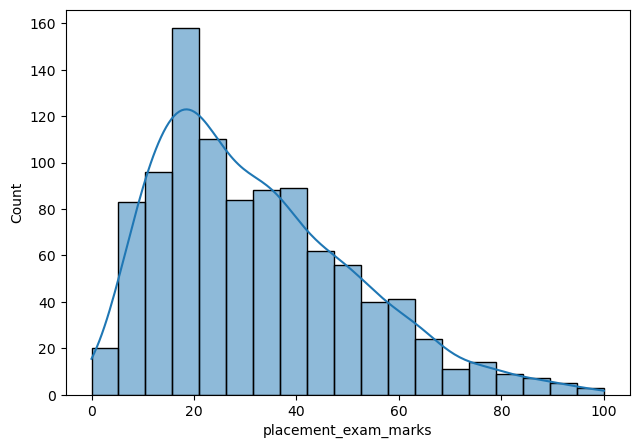

In [7]:
plt.figure(figsize=(16,5))

plt.subplot(121)
sns.histplot(data=df,x='placement_exam_marks',kde=True)

plt.show()

# by image we can found that the data is right skewed


In [8]:
df['placement_exam_marks'].skew()

np.float64(0.8356419499466834)

In [9]:
df['cgpa'].skew()

np.float64(-0.014529938929314918)

In [10]:
df['placement_exam_marks'].describe()

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

<Axes: xlabel='placement_exam_marks'>

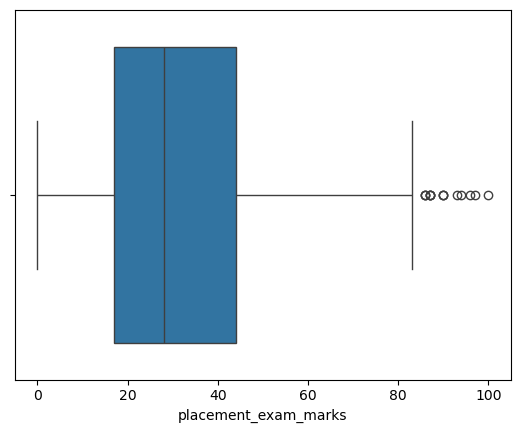

In [11]:
sns.boxplot(data=df,x='placement_exam_marks')

In [13]:
percentile25 = df['placement_exam_marks'].quantile(0.25)
percentile75 = df['placement_exam_marks'].quantile(0.75)

In [19]:
percentile25

np.float64(17.0)

In [15]:
IQR  = percentile75-percentile25

In [16]:
IQR

np.float64(27.0)

In [17]:
maximum = (percentile75+1.5*IQR)
minimum = (percentile25-1.5*IQR)

In [18]:
print(maximum , minimum)

84.5 -23.5


## FInding outliers

In [20]:
# FInding Outliers

df[df['placement_exam_marks']>maximum]

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


## Trimming

In [24]:
new_df=df[df['placement_exam_marks']<maximum]

In [25]:
new_df.shape

(985, 3)

<Axes: xlabel='placement_exam_marks'>

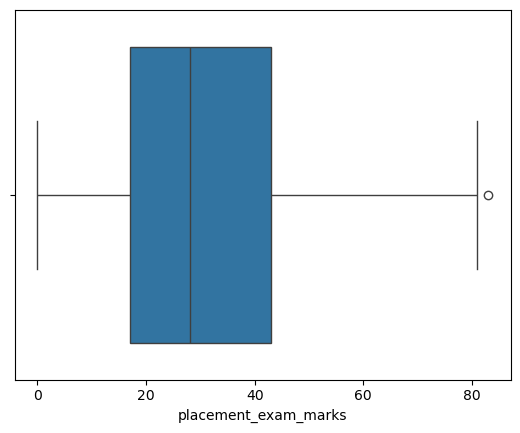

In [27]:
sns.boxplot(data=new_df,x='placement_exam_marks')

<Axes: xlabel='placement_exam_marks', ylabel='Count'>

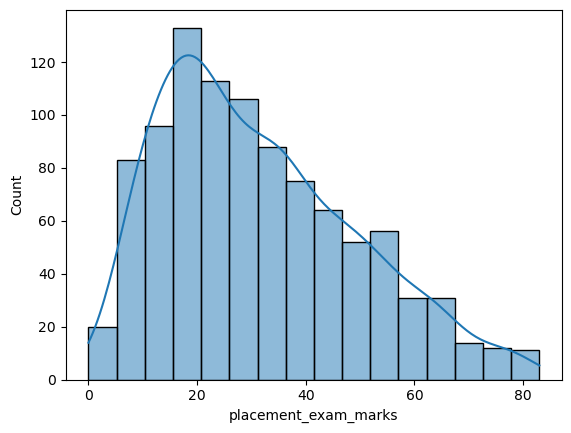

In [28]:
sns.histplot(data=new_df,x='placement_exam_marks',kde=True)

## Capping

In [30]:
new_df_cap=df.copy()

In [31]:
new_df_cap['placement_exam_marks']=np.where(
    new_df_cap['placement_exam_marks']>maximum,
    maximum,
    np.where(
        new_df_cap['placement_exam_marks']<minimum,
        minimum,
        new_df_cap['placement_exam_marks']
    )
)

In [33]:
new_df_cap.shape

(1000, 3)

<Axes: xlabel='placement_exam_marks'>

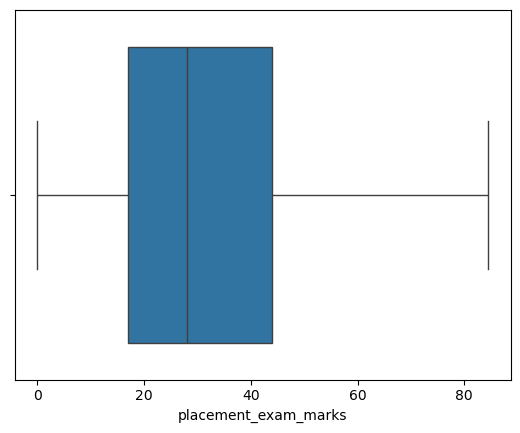

In [34]:
sns.boxplot(data=new_df_cap,x='placement_exam_marks')

<Axes: xlabel='placement_exam_marks', ylabel='Count'>

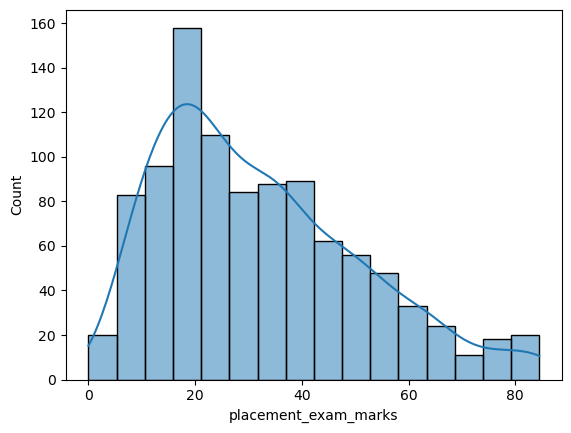

In [35]:
sns.histplot(data=new_df_cap,x='placement_exam_marks',kde=True)